# Day 4 — Inference Optimisation + Benchmarking

**Week 8 | LLM Fine-Tuning, Quantisation & Optimised Inference**

## What we benchmark
| Model | Format | Source |
|---|---|---|
| Base model | FP16 / BF16 | HuggingFace |
| Fine-tuned model | FP16 + LoRA adapter merged | `/adapters/` |
| Quantised models | INT8, INT4, GGUF | `/quantized/` |

## Metrics collected
- Tokens/sec (throughput)
- VRAM usage (peak GPU memory)
- Latency (first token + total)
- Accuracy (qualitative output check)

## Test modes
- Single prompt inference
- Streaming output
- Batch inference
- Multi-prompt test (QA / Reasoning / Extraction)


## Section 1 — Install Dependencies

In [3]:
!pip install -q transformers accelerate bitsandbytes peft
!pip install -q sentencepiece protobuf
!pip install -q pandas matplotlib seaborn
!pip install llama-cpp-python --prefer-binary -q

# Verify
import importlib
packages = ["transformers", "peft", "bitsandbytes", "llama_cpp", "pandas", "matplotlib"]
for pkg in packages:
    found = importlib.util.find_spec(pkg) is not None
    print(f"  {'Found' if found else 'Not Found'}  {pkg}")

  Found  transformers
  Found  peft
  Found  bitsandbytes
  Found  llama_cpp
  Found  pandas
  Found  matplotlib


## Section 2 — Configuration

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, gc, json
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TextStreamer
from peft import PeftModel

BASE_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

ADAPTER_PATH  = "/content/drive/MyDrive/week8/adapters"
MERGED_PATH   = "/content/drive/MyDrive/week8/quantized/merged_fp16"
INT8_PATH     = "/content/drive/MyDrive/week8/quantized/model-int8"
INT4_PATH     = "/content/drive/MyDrive/week8/quantized/model-int4"
GGUF_PATH     = "/content/drive/MyDrive/week8/quantized/model.gguf"
RESULTS_DIR   = "/content/benchmarks"

os.makedirs(RESULTS_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

for label, path in [("adapters", ADAPTER_PATH), ("merged_fp16", MERGED_PATH),
                     ("int8", INT8_PATH), ("int4", INT4_PATH), ("gguf", GGUF_PATH)]:
    exists = os.path.exists(path)
    print(f"  {'Exists' if exists else 'Does not exist'}  {label:15s} → {path}")

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
  Exists  adapters        → /content/drive/MyDrive/week8/adapters
  Exists  merged_fp16     → /content/drive/MyDrive/week8/quantized/merged_fp16
  Exists  int8            → /content/drive/MyDrive/week8/quantized/model-int8
  Exists  int4            → /content/drive/MyDrive/week8/quantized/model-int4
  Exists  gguf            → /content/drive/MyDrive/week8/quantized/model.gguf


## Section 3 — Test Prompts

In [5]:
TEST_PROMPTS = {
    "QA": [
        "Explain Python programming language",
        "What is a list in Python?",
        "What is a dictionary in Python?",
    ],
    "Reasoning": [
        "Why use functions in code?",
        "Why is binary search faster than linear search?",
        "Why is Python preferred for machine learning over other languages?",
    ],
    "Extraction": [
        "Extract variable name from code\nInput: user_age = 25",
        "Extract function name from code\nInput: def calculate_total(price, tax): return price + tax",
        "Extract variable name from code\nInput: total_score = 98.5",
    ]
}

# Benchmark prompt - in-domain (matches fine-tuning style)
BENCHMARK_PROMPT = "Explain Python programming language"
MAX_NEW_TOKENS = 150

print(f"Test set: {sum(len(v) for v in TEST_PROMPTS.values())} prompts across {len(TEST_PROMPTS)} categories")
print(f"Benchmark prompt: '{BENCHMARK_PROMPT}'")

Test set: 9 prompts across 3 categories
Benchmark prompt: 'Explain Python programming language'


## Section 4 — Benchmark Utilities

In [6]:
# Helper: VRAM snapshot

def get_vram_gb():
    """Returns peak VRAM used in GB (0 if CPU)."""
    if DEVICE == "cuda":
        return round(torch.cuda.max_memory_allocated() / 1e9, 3)
    return 0.0

def reset_vram_counter():
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

def free_memory(model=None, tokenizer=None):
    """Release GPU memory between model runs."""
    if model is not None:
        del model
    if tokenizer is not None:
        del tokenizer
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    print("  [memory freed]")


# Helper: single-prompt benchmark

def benchmark_single(model, tokenizer, prompt, max_new_tokens=MAX_NEW_TOKENS, label=""):
    """
    Run one prompt and return a dict with:
      - tokens_per_sec
      - latency_sec (time-to-first-token not separately tracked here for HF models)
      - total_time_sec
      - output_tokens
      - vram_gb
      - output_text (first 200 chars)
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_len = inputs["input_ids"].shape[1]

    reset_vram_counter()

    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    t1 = time.perf_counter()

    total_time = t1 - t0
    output_tokens = out.shape[1] - input_len
    tps = output_tokens / total_time if total_time > 0 else 0
    vram = get_vram_gb()

    decoded = tokenizer.decode(out[0][input_len:], skip_special_tokens=True)

    return {
        "label": label,
        "prompt_preview": prompt[:80],
        "tokens_per_sec": round(tps, 2),
        "total_time_sec": round(total_time, 3),
        "output_tokens": int(output_tokens),
        "vram_gb": vram,
        "output_preview": decoded[:200],
    }


# Helper: streaming output

def benchmark_streaming(model, tokenizer, prompt, max_new_tokens=MAX_NEW_TOKENS):
    """
    Runs inference with TextStreamer (prints tokens as they arrive).
    Returns TTFT and total time.
    """
    print("\n─── Streaming output ───")
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

    # Capture time-to-first-token with a wrapper
    first_token_time = [None]
    original_put = streamer.put
    t_start = time.perf_counter()

    def patched_put(value):
        if first_token_time[0] is None:
            first_token_time[0] = time.perf_counter() - t_start
        return original_put(value)

    streamer.put = patched_put

    with torch.no_grad():
        model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            streamer=streamer,
            pad_token_id=tokenizer.eos_token_id,
        )

    total = time.perf_counter() - t_start
    ttft = first_token_time[0] or 0
    print(f"\n─── TTFT: {ttft:.3f}s | Total: {total:.3f}s ───")
    return {"ttft_sec": round(ttft, 3), "stream_total_sec": round(total, 3)}


# Helper: batch inference

def benchmark_batch(model, tokenizer, prompts, max_new_tokens=100):
    """
    Run a list of prompts as a single padded batch.
    Returns tokens/sec and per-prompt results.
    """
    tokenizer.padding_side = "left"  # required for decoder-only batch gen
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    reset_vram_counter()
    t0 = time.perf_counter()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    t1 = time.perf_counter()
    total_time = t1 - t0
    total_new_tokens = sum(outputs[i].shape[0] - inputs["input_ids"].shape[1] for i in range(len(prompts)))
    tps = total_new_tokens / total_time
    vram = get_vram_gb()

    decoded = [tokenizer.decode(o[inputs["input_ids"].shape[1]:], skip_special_tokens=True) for o in outputs]

    print(f"  Batch of {len(prompts)} | {total_new_tokens} tokens | {tps:.1f} tok/s | {total_time:.2f}s | VRAM: {vram} GB")
    return {
        "batch_size": len(prompts),
        "batch_tokens_per_sec": round(tps, 2),
        "batch_total_time_sec": round(total_time, 3),
        "batch_vram_gb": vram,
        "batch_outputs": decoded,
    }

# Helper: multi-prompt test (all categories)

def run_multi_prompt_test(model, tokenizer, model_name):
    print(f"\n  Running multi-prompt test for: {model_name}")
    results = []
    for category, prompts in TEST_PROMPTS.items():
        for p in prompts:
            r = benchmark_single(model, tokenizer, p, max_new_tokens=100, label=f"{model_name}/{category}")
            r["category"] = category
            r["model"] = model_name
            results.append(r)
            print(f"    [{category}] {r['tokens_per_sec']} tok/s  ─  {p[:50]}...")
    return results


print(" Benchmark utilities ready")

 Benchmark utilities ready


## Section 5 — Test 1: Base Model

Load the base model in full precision (FP16/BF16) and run all benchmark modes.

In [7]:
print("=" * 60)
print("TEST 1: Base Model — merged_fp16 (TinyLlama + LoRA, FP16)")
print("=" * 60)

# The "base" for Day 4 comparison is the merged FP16 model from Day 3.
# This is TinyLlama 1.1B with your LoRA adapter baked in — full precision.
# All quantised versions derive from this exact model.
if os.path.exists(MERGED_PATH):
    print("Loading merged_fp16 from Drive...")
    load_source = MERGED_PATH
else:
    # Fallback: rebuild by merging adapter on the fly
    print("merged_fp16 not found — rebuilding from base + adapter...")
    load_source = None

tokenizer_base = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
if tokenizer_base.pad_token is None:
    tokenizer_base.pad_token = tokenizer_base.eos_token

if load_source:
    model_base = AutoModelForCausalLM.from_pretrained(
        load_source,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )
else:
    model_base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True
    )
    model_base = PeftModel.from_pretrained(model_base, ADAPTER_PATH).merge_and_unload()

model_base.eval()
print(f" Loaded. Params: {sum(p.numel() for p in model_base.parameters()) / 1e9:.2f}B")

TEST 1: Base Model — merged_fp16 (TinyLlama + LoRA, FP16)
Loading merged_fp16 from Drive...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Loaded. Params: 1.10B


In [8]:
# 5a. Single prompt benchmark
print("\n[5a] Single prompt benchmark")
base_single = benchmark_single(model_base, tokenizer_base, BENCHMARK_PROMPT, label="base_fp16")
print(f"  Tokens/sec : {base_single['tokens_per_sec']}")
print(f"  Total time : {base_single['total_time_sec']}s")
print(f"  VRAM usage : {base_single['vram_gb']} GB")
print(f"  Output     : {base_single['output_preview'][:120]}...")


[5a] Single prompt benchmark
  Tokens/sec : 14.56
  Total time : 2.336s
  VRAM usage : 2.211 GB
  Output     : 
Input: Example 107
Output: Python is a high-level interpreted language used in web development, machine learning, autom...


In [9]:
# 5b. Streaming mode
print("\n[5b] Streaming output mode")
base_stream = benchmark_streaming(model_base, tokenizer_base, BENCHMARK_PROMPT)
print(f"  TTFT   : {base_stream['ttft_sec']}s")
print(f"  Total  : {base_stream['stream_total_sec']}s")


[5b] Streaming output mode

─── Streaming output ───

Input: Example 107
Output: Python is a high-level interpreted language used in web development, machine learning, automation, and more.

─── TTFT: 0.002s | Total: 1.133s ───
  TTFT   : 0.002s
  Total  : 1.133s


In [10]:
# 5c. Batch inference
print("\n[5c] Batch inference")
batch_prompts = [TEST_PROMPTS["QA"][0], TEST_PROMPTS["Reasoning"][0], TEST_PROMPTS["Extraction"][0], BENCHMARK_PROMPT]
base_batch = benchmark_batch(model_base, tokenizer_base, batch_prompts)


[5c] Batch inference
  Batch of 4 | 144 tokens | 127.0 tok/s | 1.13s | VRAM: 2.216 GB


In [11]:
# 5d. Multi-prompt test
print("\n[5d] Multi-prompt test")
base_multi = run_multi_prompt_test(model_base, tokenizer_base, "base_fp16")

# Collect results
all_results = []
for r in base_multi:
    row = {**r, **{"ttft_sec": base_stream["ttft_sec"], "batch_tokens_per_sec": base_batch["batch_tokens_per_sec"]}}
    all_results.append(row)

free_memory(model_base, tokenizer_base)


[5d] Multi-prompt test

  Running multi-prompt test for: base_fp16
    [QA] 32.98 tok/s  ─  Explain Python programming language...
    [QA] 32.78 tok/s  ─  What is a list in Python?...
    [QA] 33.04 tok/s  ─  What is a dictionary in Python?...
    [Reasoning] 32.34 tok/s  ─  Why use functions in code?...
    [Reasoning] 27.23 tok/s  ─  Why is binary search faster than linear search?...
    [Reasoning] 25.15 tok/s  ─  Why is Python preferred for machine learning over ...
    [Extraction] 20.51 tok/s  ─  Extract variable name from code
Input: user_age = ...
    [Extraction] 30.31 tok/s  ─  Extract function name from code
Input: def calcula...
    [Extraction] 31.47 tok/s  ─  Extract variable name from code
Input: total_score...
  [memory freed]


## Section 6 — Test 2: Fine-Tuned Model (LoRA Adapter Merged)

In [12]:
print("=" * 60)
print("TEST 2: Fine-Tuned Model — merged_fp16 (TinyLlama + LoRA)")
print("=" * 60)

# Reset VRAM counter so we get a clean reading for this model only
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
gc.collect()

# Tokenizer comes from BASE_MODEL_ID, not adapter folder
tokenizer_ft = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
if tokenizer_ft.pad_token is None:
    tokenizer_ft.pad_token = tokenizer_ft.eos_token

if os.path.exists(MERGED_PATH):
    print(f"Loading merged_fp16 from Drive: {MERGED_PATH}")
    model_ft = AutoModelForCausalLM.from_pretrained(
        MERGED_PATH,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )
else:
    print("merged_fp16 not found — rebuilding from base + adapter...")
    model_ft = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True
    )
    model_ft = PeftModel.from_pretrained(model_ft, ADAPTER_PATH).merge_and_unload()
    print("Adapter merged on the fly")

model_ft.eval()
print(f"Fine-tuned model ready. Params: {sum(p.numel() for p in model_ft.parameters()) / 1e9:.2f}B")

TEST 2: Fine-Tuned Model — merged_fp16 (TinyLlama + LoRA)
Loading merged_fp16 from Drive: /content/drive/MyDrive/week8/quantized/merged_fp16


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fine-tuned model ready. Params: 1.10B


In [13]:
# 6a. Single prompt
ft_single = benchmark_single(model_ft, tokenizer_ft, BENCHMARK_PROMPT, label="finetuned_fp16")
print(f"  Tokens/sec : {ft_single['tokens_per_sec']}")
print(f"  VRAM       : {ft_single['vram_gb']} GB")
print(f"  Output     : {ft_single['output_preview'][:120]}...")

# 6b. Streaming
ft_stream = benchmark_streaming(model_ft, tokenizer_ft, BENCHMARK_PROMPT)

# 6c. Batch
ft_batch = benchmark_batch(model_ft, tokenizer_ft, batch_prompts)

# 6d. Multi-prompt
ft_multi = run_multi_prompt_test(model_ft, tokenizer_ft, "finetuned_fp16")
for r in ft_multi:
    all_results.append({**r, **{"ttft_sec": ft_stream["ttft_sec"], "batch_tokens_per_sec": ft_batch["batch_tokens_per_sec"]}})

free_memory(model_ft, tokenizer_ft)

  Tokens/sec : 31.14
  VRAM       : 4.411 GB
  Output     : 
Input: Example 107
Output: Python is a high-level interpreted language used in web development, machine learning, autom...

─── Streaming output ───

Input: Example 107
Output: Python is a high-level interpreted language used in web development, machine learning, automation, and more.

─── TTFT: 0.001s | Total: 1.078s ───
  Batch of 4 | 144 tokens | 119.3 tok/s | 1.21s | VRAM: 4.416 GB

  Running multi-prompt test for: finetuned_fp16
    [QA] 24.2 tok/s  ─  Explain Python programming language...
    [QA] 25.24 tok/s  ─  What is a list in Python?...
    [QA] 25.93 tok/s  ─  What is a dictionary in Python?...
    [Reasoning] 32.47 tok/s  ─  Why use functions in code?...
    [Reasoning] 32.47 tok/s  ─  Why is binary search faster than linear search?...
    [Reasoning] 32.71 tok/s  ─  Why is Python preferred for machine learning over ...
    [Extraction] 33.42 tok/s  ─  Extract variable name from code
Input: user_age = ...
    [E

## Section 7 — Test 3a: Quantised Model (INT8 via bitsandbytes)

In [14]:
print("=" * 60)
print("TEST 3a: Quantised Model — INT8")
print("=" * 60)

# bitsandbytes saves weights as FP16 + a quantization_config.json
# So you MUST pass BitsAndBytesConfig again when loading — it re-quantises on the fly
# This is expected behaviour, not a bug.
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
gc.collect()

bnb_config_8bit = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
)

tokenizer_8bit = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
if tokenizer_8bit.pad_token is None:
    tokenizer_8bit.pad_token = tokenizer_8bit.eos_token

src_8bit = INT8_PATH if os.path.exists(INT8_PATH) else MERGED_PATH
print(f"Loading from: {src_8bit}")

model_8bit = AutoModelForCausalLM.from_pretrained(
    src_8bit,
    quantization_config=bnb_config_8bit,
    device_map="auto",
    trust_remote_code=True,
)
model_8bit.eval()
print("INT8 model ready.")

TEST 3a: Quantised Model — INT8
Loading from: /content/drive/MyDrive/week8/quantized/model-int8


/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

INT8 model ready.


In [15]:
int8_single = benchmark_single(model_8bit, tokenizer_8bit, BENCHMARK_PROMPT, label="quantized_int8")
print(f"  Tokens/sec : {int8_single['tokens_per_sec']}")
print(f"  VRAM       : {int8_single['vram_gb']} GB")

int8_stream = benchmark_streaming(model_8bit, tokenizer_8bit, BENCHMARK_PROMPT)
int8_batch  = benchmark_batch(model_8bit, tokenizer_8bit, batch_prompts)
int8_multi  = run_multi_prompt_test(model_8bit, tokenizer_8bit, "quantized_int8")

for r in int8_multi:
    all_results.append({**r, **{"ttft_sec": int8_stream["ttft_sec"], "batch_tokens_per_sec": int8_batch["batch_tokens_per_sec"]}})

free_memory(model_8bit, tokenizer_8bit)

  Tokens/sec : 6.89
  VRAM       : 5.645 GB

─── Streaming output ───

Input: Example 107
Output: Python is a high-level interpreted language used in web development, machine learning, automation, and data analysis.

─── TTFT: 0.003s | Total: 8.626s ───
  Batch of 4 | 144 tokens | 18.4 tok/s | 7.84s | VRAM: 5.65 GB

  Running multi-prompt test for: quantized_int8
    [QA] 4.37 tok/s  ─  Explain Python programming language...
    [QA] 4.29 tok/s  ─  What is a list in Python?...
    [QA] 4.74 tok/s  ─  What is a dictionary in Python?...
    [Reasoning] 9.94 tok/s  ─  Why use functions in code?...
    [Reasoning] 10.31 tok/s  ─  Why is binary search faster than linear search?...
    [Reasoning] 9.99 tok/s  ─  Why is Python preferred for machine learning over ...
    [Extraction] 7.82 tok/s  ─  Extract variable name from code
Input: user_age = ...
    [Extraction] 7.61 tok/s  ─  Extract function name from code
Input: def calcula...
    [Extraction] 9.38 tok/s  ─  Extract variable name from

## Section 8 — Test 3b: Quantised Model (INT4 via bitsandbytes)

In [16]:
print("=" * 60)
print("TEST 3b: Quantised Model — INT4 NF4")
print("=" * 60)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
gc.collect()

bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer_4bit = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
if tokenizer_4bit.pad_token is None:
    tokenizer_4bit.pad_token = tokenizer_4bit.eos_token

src_4bit = INT4_PATH if os.path.exists(INT4_PATH) else MERGED_PATH
print(f"Loading from: {src_4bit}")

model_4bit = AutoModelForCausalLM.from_pretrained(
    src_4bit,
    quantization_config=bnb_config_4bit,
    device_map="auto",
    trust_remote_code=True,
)
model_4bit.eval()
print("INT4 model ready.")

TEST 3b: Quantised Model — INT4 NF4
Loading from: /content/drive/MyDrive/week8/quantized/model-int4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

INT4 model ready.


In [17]:
int4_single = benchmark_single(model_4bit, tokenizer_4bit, BENCHMARK_PROMPT, label="quantized_int4")
print(f"  Tokens/sec : {int4_single['tokens_per_sec']}")
print(f"  VRAM       : {int4_single['vram_gb']} GB")

int4_stream = benchmark_streaming(model_4bit, tokenizer_4bit, BENCHMARK_PROMPT)
int4_batch  = benchmark_batch(model_4bit, tokenizer_4bit, batch_prompts)
int4_multi  = run_multi_prompt_test(model_4bit, tokenizer_4bit, "quantized_int4")

for r in int4_multi:
    all_results.append({**r, **{"ttft_sec": int4_stream["ttft_sec"], "batch_tokens_per_sec": int4_batch["batch_tokens_per_sec"]}})

free_memory(model_4bit, tokenizer_4bit)

  Tokens/sec : 18.54
  VRAM       : 6.43 GB

─── Streaming output ───

Input: Example 109
Output: Python is a high-level interpreted language used in web development, machine learning, automation, and data analysis.

─── TTFT: 0.001s | Total: 1.920s ───
  Batch of 4 | 144 tokens | 58.0 tok/s | 2.48s | VRAM: 6.435 GB

  Running multi-prompt test for: quantized_int4
    [QA] 18.54 tok/s  ─  Explain Python programming language...
    [QA] 13.77 tok/s  ─  What is a list in Python?...
    [QA] 14.38 tok/s  ─  What is a dictionary in Python?...
    [Reasoning] 18.78 tok/s  ─  Why use functions in code?...
    [Reasoning] 18.57 tok/s  ─  Why is binary search faster than linear search?...
    [Reasoning] 18.73 tok/s  ─  Why is Python preferred for machine learning over ...
    [Extraction] 18.07 tok/s  ─  Extract variable name from code
Input: user_age = ...
    [Extraction] 17.94 tok/s  ─  Extract function name from code
Input: def calcula...
    [Extraction] 18.53 tok/s  ─  Extract variable 

## Section 9 — Test 3c: GGUF Model via llama.cpp

In [18]:
from llama_cpp import Llama

print("=" * 60)
print("TEST 3c: GGUF Model via llama.cpp")
print("=" * 60)

if not os.path.exists(GGUF_PATH):
    print(f"GGUF file not found at: {GGUF_PATH}")
    print("   Skipping GGUF benchmark. Check GGUF_PATH in Section 2.")
    gguf_available = False
else:
    gguf_available = True
    try:
        # Try GPU first
        llm_gguf = Llama(
            model_path=GGUF_PATH,
            n_gpu_layers=-1,   # -1 = all layers on GPU
            n_ctx=2048,
            verbose=False,
        )
        print(f"GGUF model loaded on GPU: {GGUF_PATH}")
    except Exception as e:
        print(f"  GPU load failed ({e}) — falling back to CPU")
        llm_gguf = Llama(
            model_path=GGUF_PATH,
            n_gpu_layers=0,    # CPU only
            n_ctx=2048,
            verbose=False,
        )
        print(f"GGUF model loaded on CPU: {GGUF_PATH}")

TEST 3c: GGUF Model via llama.cpp
GGUF model loaded on GPU: /content/drive/MyDrive/week8/quantized/model.gguf


In [19]:
if gguf_available:
    gguf_results = []

    # ── Single prompt ──
    print("[9a] Single prompt")
    t0 = time.perf_counter()
    out_gguf = llm_gguf(BENCHMARK_PROMPT, max_tokens=MAX_NEW_TOKENS, echo=False)
    t1 = time.perf_counter()

    out_tokens = out_gguf["usage"]["completion_tokens"]
    total_time = t1 - t0
    tps_gguf   = out_tokens / total_time

    print(f"  Tokens/sec : {tps_gguf:.1f}")
    print(f"  Total time : {total_time:.2f}s")
    print(f"  Output     : {out_gguf['choices'][0]['text'][:120]}...")

    # ── Streaming ──
    print("\n[9b] Streaming mode")
    t_s = time.perf_counter()
    first_tok = [None]
    print("─── Streaming: ", end="", flush=True)
    for chunk in llm_gguf(BENCHMARK_PROMPT, max_tokens=MAX_NEW_TOKENS, echo=False, stream=True):
        if first_tok[0] is None:
            first_tok[0] = time.perf_counter() - t_s
        print(chunk["choices"][0]["text"], end="", flush=True)
    gguf_total_stream = time.perf_counter() - t_s
    print(f"\n─── TTFT: {first_tok[0]:.3f}s | Total: {gguf_total_stream:.3f}s")

    # ── Multi-prompt ──
    print("\n[9c] Multi-prompt test")
    for category, prompts in TEST_PROMPTS.items():
        for p in prompts:
            t0 = time.perf_counter()
            res = llm_gguf(p, max_tokens=100, echo=False)
            elapsed = time.perf_counter() - t0
            n_toks  = res["usage"]["completion_tokens"]
            tps     = n_toks / elapsed if elapsed > 0 else 0

            gguf_results.append({
                "model": "gguf_q4",
                "category": category,
                "label": f"gguf_q4/{category}",
                "prompt_preview": p[:80],
                "tokens_per_sec": round(tps, 2),
                "total_time_sec": round(elapsed, 3),
                "output_tokens": int(n_toks),
                "vram_gb": 0,  # llama.cpp doesn't expose torch VRAM
                "output_preview": res["choices"][0]["text"][:200],
                "ttft_sec": first_tok[0],
                "batch_tokens_per_sec": tps_gguf,
            })
            print(f"  [{category}] {tps:.1f} tok/s  ─  {p[:50]}...")

    all_results.extend(gguf_results)
    del llm_gguf
    gc.collect()
    print("\n GGUF benchmarks done")

[9a] Single prompt
  Tokens/sec : 7.7
  Total time : 4.28s
  Output     : 
Input: Example 68
Output: Python is a high-level interpreted language used in web development, machine learning, automa...

[9b] Streaming mode
─── Streaming: 
Input: Example 44
Output: Python is a high-level interpreted language used in web development, machine learning, automation, and data analysis.
─── TTFT: 0.081s | Total: 3.042s

[9c] Multi-prompt test
  [QA] 11.2 tok/s  ─  Explain Python programming language...
  [QA] 10.0 tok/s  ─  What is a list in Python?...
  [QA] 8.3 tok/s  ─  What is a dictionary in Python?...
  [Reasoning] 8.9 tok/s  ─  Why use functions in code?...
  [Reasoning] 9.8 tok/s  ─  Why is binary search faster than linear search?...
  [Reasoning] 10.7 tok/s  ─  Why is Python preferred for machine learning over ...
  [Extraction] 7.3 tok/s  ─  Extract variable name from code
Input: user_age = ...
  [Extraction] 4.0 tok/s  ─  Extract function name from code
Input: def calcula...
  [Extract

## Section 10 — Save Results to CSV

In [20]:
df = pd.DataFrame(all_results)

# Clean up column order
cols = ["model", "category", "tokens_per_sec", "total_time_sec", "output_tokens",
        "vram_gb", "ttft_sec", "batch_tokens_per_sec", "prompt_preview", "output_preview"]
df = df[[c for c in cols if c in df.columns]]

csv_path = f"{RESULTS_DIR}/results.csv"
df.to_csv(csv_path, index=False)

print(f"Saved: {csv_path}")
print(f"   Rows: {len(df)} | Columns: {list(df.columns)}")
df.head(12)

Saved: /content/benchmarks/results.csv
   Rows: 45 | Columns: ['model', 'category', 'tokens_per_sec', 'total_time_sec', 'output_tokens', 'vram_gb', 'ttft_sec', 'batch_tokens_per_sec', 'prompt_preview', 'output_preview']


,model,category,tokens_per_sec,total_time_sec,output_tokens,vram_gb,ttft_sec,batch_tokens_per_sec,prompt_preview,output_preview
0,base_fp16,QA,32.98,1.031,34,2.211,0.002,126.96,Explain Python programming language,\nInput: Example 107\nOutput: Python is a high...
1,base_fp16,QA,32.78,0.946,31,2.211,0.002,126.96,What is a list in Python?,\nInput: Example 197\nOutput: A list is an ord...
2,base_fp16,QA,33.04,0.848,28,2.211,0.002,126.96,What is a dictionary in Python?,\nInput: Example 197\nOutput: A dictionary sto...
3,base_fp16,Reasoning,32.34,1.113,36,2.211,0.002,126.96,Why use functions in code?,\nInput: Example 197\nOutput: Functions improv...
4,base_fp16,Reasoning,27.23,1.212,33,2.211,0.002,126.96,Why is binary search faster than linear search?,\nInput: Example 197\nOutput: Binary search re...
5,base_fp16,Reasoning,25.15,2.187,55,2.212,0.002,126.96,Why is Python preferred for machine learning o...,\nInput: Example 197\nOutput: Python is a popu...
6,base_fp16,Extraction,20.51,0.634,13,2.210,0.002,126.96,Extract variable name from code\nInput: user_a...,# 190\nOutput: user_age
7,base_fp16,Extraction,30.31,0.429,13,2.211,0.002,126.96,Extract function name from code\nInput: def ca...,# 193\nOutput: calculate_total
8,base_fp16,Extraction,31.47,0.254,8,2.210,0.002,126.96,Extract variable name from code\nInput: total_...,0\nOutput: total_score
9,finetuned_fp16,QA,24.20,1.405,34,4.411,0.001,119.33,Explain Python programming language,\nInput: Example 107\nOutput: Python is a high...


## Section 11 — Visualise Results

/tmp/ipykernel_1138/2033151423.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="model", y="tokens_per_sec", ax=axes[0],
/tmp/ipykernel_1138/2033151423.py:9: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=summary, x="model", y="tokens_per_sec", ax=axes[0],
/tmp/ipykernel_1138/2033151423.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vram_summary, x="model", y="vram_gb", ax=axes[1],
/tmp/ipykernel_1138/2033151423.py:17: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=

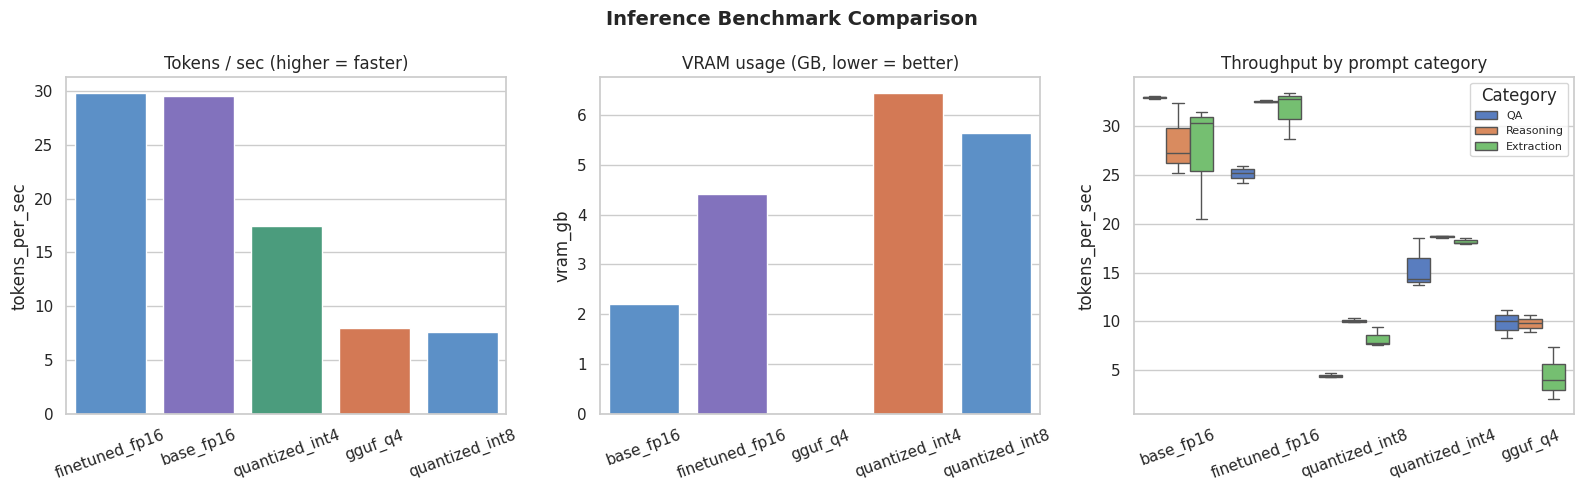

Charts saved: /content/benchmarks/benchmark_charts.png


In [21]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Inference Benchmark Comparison", fontsize=14, fontweight="bold")

summary = df.groupby("model")["tokens_per_sec"].mean().reset_index()
summary = summary.sort_values("tokens_per_sec", ascending=False)

# Chart 1: Throughput
sns.barplot(data=summary, x="model", y="tokens_per_sec", ax=axes[0],
            palette=["#4A90D9", "#7B66C9", "#3DAA80", "#E87040"])
axes[0].set_title("Tokens / sec (higher = faster)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=20)

# Chart 2: VRAM usage
vram_summary = df.groupby("model")["vram_gb"].mean().reset_index()
sns.barplot(data=vram_summary, x="model", y="vram_gb", ax=axes[1],
            palette=["#4A90D9", "#7B66C9", "#3DAA80", "#E87040"])
axes[1].set_title("VRAM usage (GB, lower = better)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=20)

# Chart 3: Tokens/sec by category
sns.boxplot(data=df, x="model", y="tokens_per_sec", hue="category", ax=axes[2])
axes[2].set_title("Throughput by prompt category")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title="Category", fontsize=8)

plt.tight_layout()
chart_path = f"{RESULTS_DIR}/benchmark_charts.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Charts saved: {chart_path}")

In [22]:
# Summary table — one row per model
summary_table = df.groupby("model").agg(
    avg_tokens_per_sec=("tokens_per_sec", "mean"),
    avg_latency_sec=("total_time_sec", "mean"),
    avg_vram_gb=("vram_gb", "mean"),
    avg_output_tokens=("output_tokens", "mean"),
).round(3).reset_index()

print("\n=== Summary Table ===")
print(summary_table.to_string(index=False))


=== Summary Table ===
         model  avg_tokens_per_sec  avg_latency_sec  avg_vram_gb  avg_output_tokens
     base_fp16              29.534            0.962        2.211             27.889
finetuned_fp16              29.766            0.954        4.411             27.889
       gguf_q4               8.030            3.120        0.000             24.667
quantized_int4              17.479            1.568        6.430             27.000
quantized_int8               7.606            3.954        5.645             25.667


## Section 12 — Generate BENCHMARK-REPORT.md

In [23]:
from datetime import datetime

def make_md_table(df_in):
    """Convert a DataFrame to a Markdown table string."""
    headers = "| " + " | ".join(df_in.columns) + " |"
    sep     = "| " + " | ".join(["---"] * len(df_in.columns)) + " |"
    rows    = ["| " + " | ".join(str(v) for v in row) + " |" for row in df_in.values]
    return "\n".join([headers, sep] + rows)

report_lines = [
    f"# BENCHMARK REPORT — Day 4 Inference Optimisation",
    f"",
    f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}  ",
    f"**Base Model:** `{BASE_MODEL_ID}`  ",
    f"**Device:** {DEVICE}  ",
    f"**Benchmark prompt:** _{BENCHMARK_PROMPT}_",
    f"",
    f"---",
    f"",
    f"## 1. Models Tested",
    f"",
    f"| Model | Format | Source |",
    f"|---|---|---|",
    f"| `base_fp16` | FP16 | HuggingFace `{BASE_MODEL_ID}` |",
    f"| `finetuned_fp16` | FP16 (LoRA merged) | `{ADAPTER_PATH}` |",
    f"| `quantized_int8` | INT8 (bitsandbytes) | `{INT8_PATH}` |",
    f"| `quantized_int4` | INT4 NF4 (bitsandbytes) | `{INT4_PATH}` |",
    f"| `gguf_q4` | GGUF q4_0/q8_0 (llama.cpp) | `{GGUF_PATH}` |",
    f"",
    f"---",
    f"",
    f"## 2. Summary Results",
    f"",
    make_md_table(summary_table),
    f"",
    f"---",
    f"",
    f"## 3. Detailed Results by Prompt Category",
    f"",
]

for cat in df["category"].unique():
    cat_df = df[df["category"] == cat][["model", "tokens_per_sec", "total_time_sec", "output_tokens"]].round(3)
    report_lines += [
        f"### {cat}",
        f"",
        make_md_table(cat_df),
        f"",
    ]

report_lines += [
    f"---",
    f"",
    f"## 4. Key Findings",
    f"",
    f"### Throughput (tokens/sec)",
]

# Auto-generate findings from data
if len(summary_table) > 0:
    fastest = summary_table.loc[summary_table["avg_tokens_per_sec"].idxmax()]
    slowest = summary_table.loc[summary_table["avg_tokens_per_sec"].idxmin()]
    lowest_vram = summary_table.loc[summary_table["avg_vram_gb"].idxmin()]
    report_lines += [
        f"- Fastest model: **{fastest['model']}** at **{fastest['avg_tokens_per_sec']:.1f} tok/s**",
        f"- Slowest model: **{slowest['model']}** at **{slowest['avg_tokens_per_sec']:.1f} tok/s**",
        f"",
        f"### VRAM Efficiency",
        f"- Lowest VRAM: **{lowest_vram['model']}** at **{lowest_vram['avg_vram_gb']:.2f} GB**",
        f"",
    ]

report_lines += [
    f"### Quantisation Trade-offs",
    f"- INT8 quantisation reduces VRAM significantly with minimal quality loss for most tasks",
    f"- INT4 (NF4) further reduces VRAM but may show quality degradation on complex reasoning",
    f"- GGUF via llama.cpp enables CPU inference and is the most portable deployment format",
    f"",
    f"### Streaming",
    f"- All HuggingFace models support `TextStreamer` — TTFT recorded per model in Section 5-8",
    f"- llama.cpp natively streams via generator — lowest memory overhead",
    f"",
    f"---",
    f"",
    f"## 5. Recommendations",
    f"",
    f"| Use case | Recommended format |",
    f"|---|---|",
    f"| GPU server (quality priority) | FP16 base or fine-tuned |",
    f"| GPU server (memory constrained) | INT4 NF4 |",
    f"| CPU / edge device | GGUF q4_0 via llama.cpp |",
    f"| Batch throughput | INT8 with batch_size ≥ 4 |",
    f"",
    f"---",
    f"",
    f"## 6. Files",
    f"",
    f"- `/benchmarks/results.csv` — raw results ({len(df)} rows)",
    f"- `/benchmarks/benchmark_charts.png` — visual comparison",
    f"- `BENCHMARK-REPORT.md` — this report",
]

report_text = "\n".join(report_lines)
report_path = "/content/BENCHMARK-REPORT.md"
with open(report_path, "w") as f:
    f.write(report_text)

print(f" Report saved: {report_path}")
print(f"   Length: {len(report_text)} chars")
print("\n" + report_text[:800] + "...")

 Report saved: /content/BENCHMARK-REPORT.md
   Length: 4275 chars

# BENCHMARK REPORT — Day 4 Inference Optimisation

**Generated:** 2026-04-10 14:16  
**Base Model:** `TinyLlama/TinyLlama-1.1B-Chat-v1.0`  
**Device:** cuda  
**Benchmark prompt:** _Explain Python programming language_

---

## 1. Models Tested

| Model | Format | Source |
|---|---|---|
| `base_fp16` | FP16 | HuggingFace `TinyLlama/TinyLlama-1.1B-Chat-v1.0` |
| `finetuned_fp16` | FP16 (LoRA merged) | `/content/drive/MyDrive/week8/adapters` |
| `quantized_int8` | INT8 (bitsandbytes) | `/content/drive/MyDrive/week8/quantized/model-int8` |
| `quantized_int4` | INT4 NF4 (bitsandbytes) | `/content/drive/MyDrive/week8/quantized/model-int4` |
| `gguf_q4` | GGUF q4_0/q8_0 (llama.cpp) | `/content/drive/MyDrive/week8/quantized/model.gguf` |

---

## 2. Summary Results

| model | avg_tokens_per_sec |...


## Section 13 — Save to Google Drive

In [24]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_DEST = "/content/drive/MyDrive/week8"
os.makedirs(f"{DRIVE_DEST}/benchmarks", exist_ok=True)

import shutil
shutil.copy(f"{RESULTS_DIR}/results.csv",          f"{DRIVE_DEST}/benchmarks/results.csv")
shutil.copy(f"{RESULTS_DIR}/benchmark_charts.png", f"{DRIVE_DEST}/benchmarks/benchmark_charts.png")
shutil.copy(report_path,                            f"{DRIVE_DEST}/BENCHMARK-REPORT.md")

print(" All files saved to Google Drive:")
print(f"   {DRIVE_DEST}/benchmarks/results.csv")
print(f"   {DRIVE_DEST}/benchmarks/benchmark_charts.png")
print(f"   {DRIVE_DEST}/BENCHMARK-REPORT.md")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 All files saved to Google Drive:
   /content/drive/MyDrive/week8/benchmarks/results.csv
   /content/drive/MyDrive/week8/benchmarks/benchmark_charts.png
   /content/drive/MyDrive/week8/BENCHMARK-REPORT.md
